In [ ]:
!pip install ultralytics

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
zip_path = "/content/classification_dataset.zip"   # your uploaded file
extract_path = "/content/dataset"                  # extraction folder

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['classification_dataset']

In [ ]:
dataset_path = "/content/dataset/classification_dataset"

train_path = dataset_path + "/train"
val_path   = dataset_path + "/valid"
test_path  = dataset_path + "/test"

In [ ]:
def count_images(path):
    for cls in os.listdir(path):
        print(cls, ":", len(os.listdir(os.path.join(path, cls))))

print("TRAIN:")
count_images(train_path)
print("\nVALID:")
count_images(val_path)
print("\nTEST:")
count_images(test_path)

TRAIN:
bird : 1414
drone : 1248

VALID:
bird : 217
drone : 225

TEST:
bird : 121
drone : 94


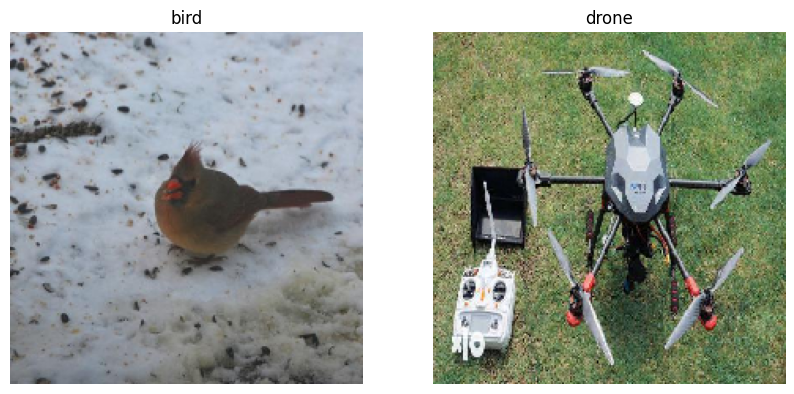

In [ ]:
import random
from tensorflow.keras.preprocessing import image

def show_images(path):
    classes = os.listdir(path)
    plt.figure(figsize=(10,5))

    for i, cls in enumerate(classes):
        img_name = random.choice(os.listdir(os.path.join(path, cls)))
        img_path = os.path.join(path, cls, img_name)
        img = image.load_img(img_path, target_size=(224,224))

        plt.subplot(1,2,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_images(train_path)

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32, class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path, target_size=(224,224), batch_size=32, class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,473 (42.61 MB)

 Trainable params: 11,169,281 (42.61 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)
checkpoint_cnn = ModelCheckpoint("best_cnn_model.h5", save_best_only=True)

In [ ]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop, checkpoint_cnn]
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6065 - loss: 5.1222

84/84 ━━━━━━━━━━━━━━━━━━━━ 487s 6s/step - accuracy: 0.6232 - loss: 2.4745 - val_accuracy: 0.6425 - val_loss: 0.6482
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6701 - loss: 0.5979

84/84 ━━━━━━━━━━━━━━━━━━━━ 500s 6s/step - accuracy: 0.6732 - loss: 0.6070 - val_accuracy: 0.6403 - val_loss: 0.6466
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6884 - loss: 0.5891

84/84 ━━━━━━━━━━━━━━━━━━━━ 512s 6s/step - accuracy: 0.6901 - loss: 0.5902 - val_accuracy: 0.6968 - val_loss: 0.6314
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7032 - loss: 0.5920

84/84 ━━━━━━━━━━━━━━━━━━━━ 561s 7s/step - accuracy: 0.6995 - loss: 0.5850 - val_accuracy: 0.7036 - val_loss: 0.5491
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7139 - loss: 0.5718

84/84 ━━━━━━━━━━━━━━━━━━━━ 514s 6s/step - accuracy: 0.7107 - loss: 0.5689 - val_accuracy: 0.7059 - val_loss: 0.5481


In [ ]:
def build_model(base_model):
    base_model.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs=base_model.input, outputs=output)

In [ ]:
mobilenet = build_model(
    tf.keras.applications.MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
)
mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mobilenet_history = mobilenet.fit(train_data, validation_data=val_data, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9080 - loss: 0.2143 - val_accuracy: 0.9593 - val_loss: 0.1072
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9606 - loss: 0.1055 - val_accuracy: 0.9502 - val_loss: 0.1249
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.9692 - loss: 0.0896 - val_accuracy: 0.9661 - val_loss: 0.0847
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9707 - loss: 0.0761 - val_accuracy: 0.9661 - val_loss: 0.0954
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.9778 - loss: 0.0631 - val_accuracy: 0.9570 - val_loss: 0.1138


In [ ]:
resnet = build_model(
    tf.keras.applications.ResNet50(input_shape=(224,224,3), include_top=False, weights='imagenet')
)
resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

resnet_history = resnet.fit(train_data, validation_data=val_data, epochs=5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 606s 7s/step - accuracy: 0.5804 - loss: 0.6808 - val_accuracy: 0.6471 - val_loss: 0.6242
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.6176 - loss: 0.6530 - val_accuracy: 0.6652 - val_loss: 0.6175
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 593s 7s/step - accuracy: 0.6180 - loss: 0.6525 - val_accuracy: 0.6697 - val_loss: 0.6079
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 591s 7s/step - accuracy: 0.6439 - loss: 0.6377 - val_accuracy: 0.6719 - val_loss: 0.5993
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 585s 7s/step - accuracy: 0.6454 - loss: 0.6279 - val_accuracy: 0.6765 - val_loss: 0.5907


In [ ]:
efficient = build_model(
    tf.keras.applications.EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
)
efficient.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

efficient_history = efficient.fit(train_data, validation_data=val_data, epochs=5)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.5162 - loss: 0.7077 - val_accuracy: 0.5090 - val_loss: 0.6934
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.5105 - loss: 0.6939 - val_accuracy: 0.4910 - val_loss: 0.6945
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.5113 - loss: 0.6932 - val_accuracy: 0.4910 - val_loss: 0.6933
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 314s 3s/step - accuracy: 0.5312 - loss: 0.6924 - val_accuracy: 0.4910 - val_loss: 0.6936
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.5282 - loss: 0.6922 - val_accuracy: 0.4910 - val_loss: 0.6941


In [ ]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 215 images belonging to 2 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step


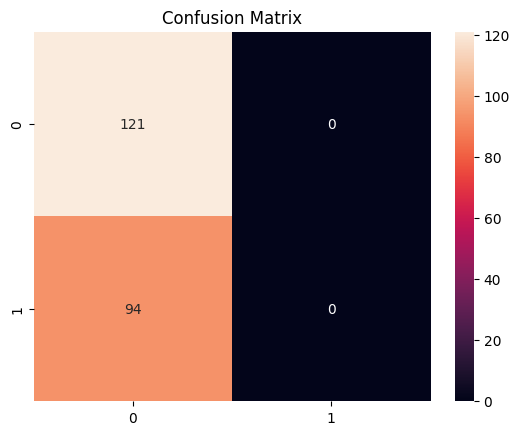

              precision    recall  f1-score   support

           0       0.56      1.00      0.72       121
           1       0.00      0.00      0.00        94

    accuracy                           0.56       215
   macro avg       0.28      0.50      0.36       215
weighted avg       0.32      0.56      0.41       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
preds = efficient.predict(test_data)
y_pred = (preds > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(test_data.classes, y_pred))

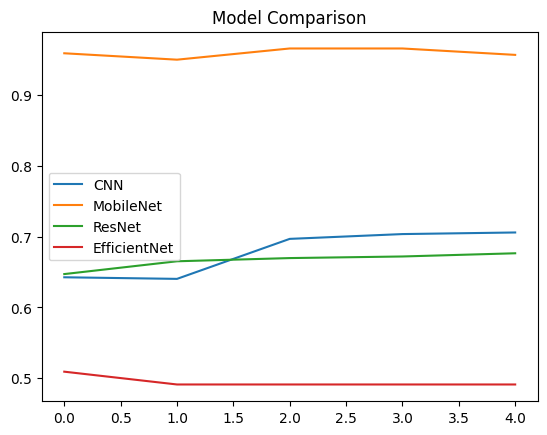

In [ ]:
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNet')
plt.plot(resnet_history.history['val_accuracy'], label='ResNet')
plt.plot(efficient_history.history['val_accuracy'], label='EfficientNet')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
efficient.save("best_model.h5")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# TRAIN YOLO
# model.train(data="data.yaml", epochs=5)

# INFERENCE
# model.predict("test.jpg", show=True)

In [ ]:
%%writefile app.py
import streamlit as st
from PIL import Image
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("best_model.h5")

st.title("Bird vs Drone Classifier")

file = st.file_uploader("Upload Image")

if file:
    img = Image.open(file).resize((224,224))
    st.image(img)

    img = np.array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)

    if pred > 0.5:
        st.write("Drone Detected")
    else:
        st.write("Bird Detected")

Overwriting app.py
